In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('Dataset.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.shape

(3900, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

---
Dataset contains 3900 records and 18 columns.

No major datatype issues found.

'Review Rating' have Null values   

---

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


> **Age**

Minimum Age : 18  Maximum Age : 70  Average Age : 44.068462

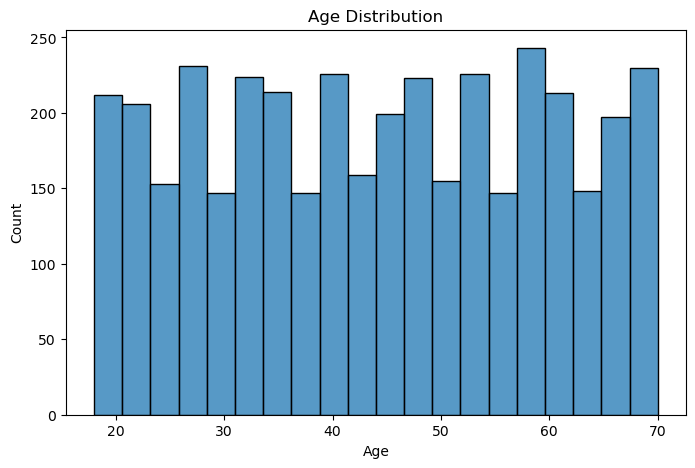

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

> Ratings

Average rating: 3.75 / 5
indicates generally satisfied customers.
customer sentiment appears positive overall.

> **Purchase Amount**

Average purchase amount : 59.764359
 Highest purchase amount : 100.00
 Lowest purchase amount : 20.00

> Previous Purchases

Many customers have repeated purchases.
Avg : 25.351538

# Missing Values

In [8]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

missing values are only 37 / 3900 = 0.95%

In [9]:
df['Review Rating'] = (
    df['Review Rating']
    .fillna(df['Review Rating'].median())
)

# Revenue Analysis

In [10]:
df['Purchase Amount (USD)'].sum()

np.int64(233081)

In [11]:
df['Purchase Amount (USD)'].mean()

np.float64(59.76435897435898)

>Revenue by Gender

In [12]:
df.groupby('Gender')['Purchase Amount (USD)'].sum()

Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64

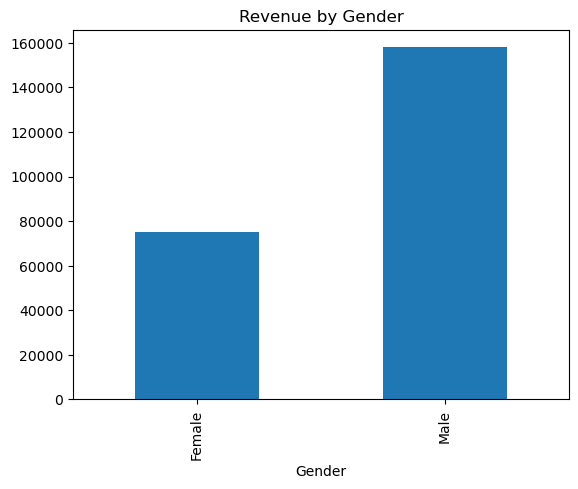

In [13]:
df.groupby('Gender')['Purchase Amount (USD)'].sum().plot(kind='bar')
plt.title("Revenue by Gender")
plt.show()

Male customers generated more revenue than female customers.

>Revenue by Category

In [14]:
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

print(category_sales)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


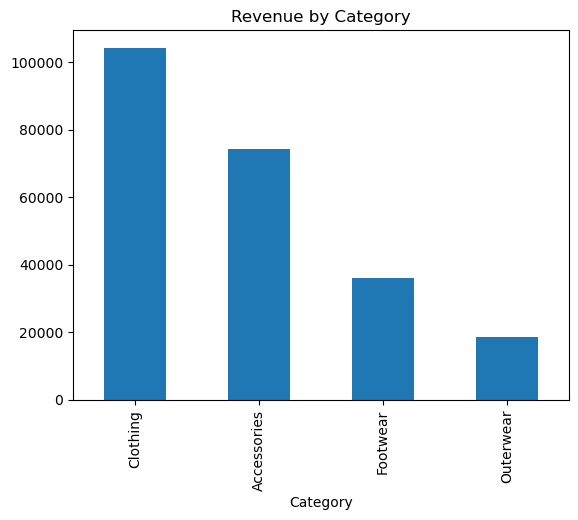

In [15]:
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

Clothing generated the highest revenue, while Outerwear generated the lowest revenue.

>Revenue by Location

In [16]:
location_sales = (
    df.groupby('Location')['Purchase Amount (USD)']
    .sum()
    .sort_values(ascending=False)
)

print(location_sales.head(10))

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase Amount (USD), dtype: int64


Top 10 revenue generating locations identified.

# Discount Analysis

In [17]:
df['Discount Applied'].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

In [18]:
df.groupby('Discount Applied')['Purchase Amount (USD)'].mean()

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

customers spend is almost same 

# Subscription Analysis

In [19]:
df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64

Almost Same here also

# For categorical columns:

In [20]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [21]:
df['Category'].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [22]:
df['Season'].value_counts()

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

In [23]:
df['Payment Method'].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [24]:
df['Subscription Status'].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

| Column   | Most Frequent Value |
| -------- | ------------------- |
| Gender   | Male(2652)          |
| Category | Clothing(1737)      |
| Season   | Almost same all     |
|Subscription Status| NO(2847)   |


---

# Customer Behavior Analysis

>1. Gender Distribution

In [25]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

> 2. Category Distribution

In [26]:
df['Category'].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

> 3. Subscription Status

In [27]:
df['Subscription Status'].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

> 4. Total Revenue

In [28]:
#This gives total sales generated
df['Purchase Amount (USD)'].sum()

np.int64(233081)

---
---

# Key Insights from EDA

## Customer Demographics

- Total customers: 3900
- Average customer age: 44 years
- Male customers account for 68% of customers.
- Female customers account for 32% of customers.

## Product Categories

- Clothing is the most popular category with 1,737 purchases.
- Outerwear is the least purchased category with 324 purchases.

## Revenue Analysis

- Total revenue generated: $233,081.
- Average purchase amount: $59.76.
- Male customers generated more revenue ($157,890) than female customers ($75,191).

## Category Performance

- Clothing generated the highest revenue ($104,264).
- Outerwear generated the lowest revenue ($18,524).

## Discount Analysis

- Customers spend nearly the same amount with or without discounts.
- Discounts do not appear to significantly increase spending.

## Subscription Analysis

- Subscribers and non-subscribers have similar average purchase amounts.
- Current subscription status does not strongly influence spending behavior.

---
---

<div style="background-color: #2c3e50; padding: 15px; border-radius: 6px; text-align: center;">
    <h2 style="color: #ffffff; margin: 0; font-family: 'Segoe UI', sans-serif; letter-spacing: 2px;">FEATURE ENGINEERING</h2>
</div>

In [29]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [30]:
df['Customer Value Score'] = df['Purchase Amount (USD)'] * df['Previous Purchases']

In [31]:
df['Customer Value Score'].describe()

count    3900.000000
mean     1517.876923
std      1116.943053
min        21.000000
25%       619.000000
50%      1278.000000
75%      2211.750000
max      5000.000000
Name: Customer Value Score, dtype: float64

In [32]:
# Calculate Quartiles based on the new valid score
q1 = df['Customer Value Score'].quantile(0.25)
q3 = df['Customer Value Score'].quantile(0.75)


print(q1)
print(q3)

619.0
2211.75


In [33]:
def value_tier(score):
    if score >= q3:
        return "High Value"
    elif score <= q1:
        return "Low Value"
    else:
        return "Medium Value"

df['Customer Value Tier'] = df['Customer Value Score'].apply(value_tier)
df['Customer Value Tier'].value_counts()


Customer Value Tier
Medium Value    1950
Low Value        975
High Value       975
Name: count, dtype: int64

In [34]:
print(df[['Purchase Amount (USD)', 'Previous Purchases', 'Customer Value Score', 'Customer Value Tier']].head())

   Purchase Amount (USD)  Previous Purchases  Customer Value Score  \
0                     53                  14                   742   
1                     64                   2                   128   
2                     73                  23                  1679   
3                     90                  49                  4410   
4                     49                  31                  1519   

  Customer Value Tier  
0        Medium Value  
1           Low Value  
2        Medium Value  
3          High Value  
4        Medium Value  


## Customer Value Score

A Customer Value Score was created using Purchase Amount and Previous Purchases.

Customers were segmented into:

- High Value
- Medium Value
- Low Value

This feature helps identify the most profitable customer groups.

## Customer Value Segmentation

A Customer Value Score was created using Purchase Amount and Previous Purchases.

Customers were classified into three groups:

- High Value Customers: 975
- Medium Value Customers: 1950
- Low Value Customers: 975

The majority of customers fall into the Medium Value segment. High Value customers represent approximately 25% of the customer base and should be prioritized for retention and loyalty programs.

# Promo Dependency Score

## Promo Dependency Score

A Promo Dependency Score was created using:

Discount Applied and Promo Code Used contain identical information in this dataset, therefore both variables produce the same dependency pattern.

Customers were segmented into:

- Low Dependency
- High Dependency

This feature helps identify customers who rely heavily on discounts and promotional offers before making purchases.

In [35]:
# Convert to a binary flag (1 for dependent, 0 for independent)
df['Promo Dependency Score'] = df['Discount Applied'].apply(lambda x: 1 if x == 'Yes' else 0)

In [36]:
def promo_label(score):
    if score == 1:
        return "High Dependency"
    else:
        return "Low Dependency"



In [37]:
df['Promo Dependency Level'] = df['Promo Dependency Score'].apply(promo_label)
print(df['Promo Dependency Level'].value_counts())

Promo Dependency Level
Low Dependency     2223
High Dependency    1677
Name: count, dtype: int64


## Promo Dependency Analysis

Customers were divided into two groups:

- Low Dependency: 2223 customers
- High Dependency: 1677 customers

No customers were classified as Moderate Dependency because discount usage and promo code usage always occur together in the dataset.

Approximately 43% of customers exhibit high promotional dependency, suggesting that a significant portion of customers rely on discounts and promotional offers before making purchases.

# Satisfaction Flag

| Rating  | Category    |
| ------- | ----------- |
| 4–5     | Satisfied   |
| Below 4 | Unsatisfied |


In [38]:
def satisfaction(rating):
    
    if rating >= 4:
        return "Satisfied"
    
    else:
        return "Unsatisfied"

In [39]:
df['Satisfaction Flag'] = (df['Review Rating'].apply(satisfaction))

In [40]:
df['Satisfaction Flag'].value_counts()

Satisfaction Flag
Unsatisfied    2266
Satisfied      1634
Name: count, dtype: int64

# Loyalty Definition Comparison

## Loyalty Score V1

Based on:
- Previous Purchases
- Purchase Frequency
- Subscription Status

Advantages:
- Measures engagement and repeat buying behavior.

## Loyalty Score V2

Based on:
- Review Rating
- Previous Purchases
- Promotional Dependency

Advantages:
- Measures both satisfaction and retention.

## Selected Definition

Loyalty Score V2 was selected for final business analysis because it incorporates both customer satisfaction and purchasing behavior.

> Loyalty Score V1


In [41]:
frequency_map = {
    'Weekly': 5,
    'Fortnightly': 4,
    'Bi-Weekly': 4,
    'Monthly': 3,
    'Quarterly': 2,
    'Every 3 Months': 2,
    'Annually': 1
}

df['Frequency Score'] = df['Frequency of Purchases'].map(frequency_map)

In [42]:
df['Subscription Bonus'] = np.where(
    df['Subscription Status'] == 'Yes',
    10,
    0
)
df['Loyalty Score V1'] = (
    df['Previous Purchases']
    + df['Frequency Score']
    + df['Subscription Bonus']
)

In [43]:
df['Loyalty Score V1'].describe()

count    3900.000000
mean       31.019744
std        15.311450
min         2.000000
25%        18.000000
50%        31.000000
75%        44.000000
max        65.000000
Name: Loyalty Score V1, dtype: float64

In [44]:
q1 = df['Loyalty Score V1'].quantile(0.25)
q3 = df['Loyalty Score V1'].quantile(0.75)

print("Q1 =", q1)
print("Q3 =", q3)

Q1 =ERROR! Session/line number was not unique in database. History logging moved to new session 7
 18.0
Q3 = 44.0


In [45]:
def loyalty_level_v1(score):

    if score >= q3:
        return 'High Loyalty'

    elif score <= q1:
        return 'Low Loyalty'

    else:
        return 'Medium Loyalty'

In [46]:
df['Loyalty Level V1'] = (
    df['Loyalty Score V1']
    .apply(loyalty_level_v1)
)

In [47]:
df['Loyalty Level V1'].value_counts()

Loyalty Level V1
Medium Loyalty    1928
Low Loyalty        986
High Loyalty       986
Name: count, dtype: int64

>Loyalty Score V2

**A loyal customer:**

Gives good ratings

Has many previous purchases

Is NOT highly dependent on discounts

To combine Previous Purchases and Review Rating into a single mathematical score, they must first be scaled to the exact same range (‭$0$‬ to ‭$1$‬) using Min-Max Normalization:

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize both variables to a 0-1 scale so they hold equal mathematical weight
df[['Scaled_Purchases', 'Scaled_Rating']] = scaler.fit_transform(df[['Previous Purchases', 'Review Rating']])

# Calculate a composite score (Average of scaled metrics)
df['Loyalty Base Score V2'] = (df['Scaled_Purchases'] + df['Scaled_Rating']) / 2

# Apply a mathematical penalty (e.g., 20% reduction) if they rely on promos, 
# as discount dependency erodes true brand loyalty/margins.
df['Loyalty Score V2'] = np.where(df['Promo Dependency Score'] == 1, 
                                  df['Loyalty Base Score V2'] * 0.8, 
                                  df['Loyalty Base Score V2'])
df['Loyalty Score V2'].describe()

count    3900.000000
mean        0.455534
std         0.195672
min         0.000000
25%         0.313061
50%         0.448367
75%         0.589061
max         0.980000
Name: Loyalty Score V2, dtype: float64

In [49]:

# Segment based on the new normalized quantiles
q1_v2 = df['Loyalty Score V2'].quantile(0.25)
q3_v2 = df['Loyalty Score V2'].quantile(0.75)

def loyalty_level_v2(score):
    if score >= q3_v2:
        return 'High Loyalty'
    elif score <= q1_v2:
        return 'Low Loyalty'
    else:
        return 'Medium Loyalty'

df['Loyalty Level V2'] = df['Loyalty Score V2'].apply(loyalty_level_v2)
print(df['Loyalty Level V2'].value_counts())

Loyalty Level V2
Medium Loyalty    1947
High Loyalty       977
Low Loyalty        976
Name: count, dtype: int64


# Customer Value Tier
| Tier         | Customers |
| ------------ | --------- |
| High Value   | 975       |
| Medium Value | 1950      |
| Low Value    | 975     |


# Promo Dependency
| Level           | Customers |
| --------------- | --------- |
| High Dependency | 1677      |
| Low Dependency  | 2223      |

About 43% of customers are highly dependent on promotions, which suggests discounts play an important role for a large customer segment.


# Loyalty Score V1
**Based On**

•Previous Purchases

•Frequency Score

•Subscription Bonus

| Level          | Customers |
| -------------- | --------- |
| High Loyalty   | 986       |
| Medium Loyalty | 1928      |
| Low Loyalty    | 986     |

# Loyalty Score V2
**Based On**

•Review Rating

•Previous Purchases

•Promo Dependency
| Level          | Customers |
| -------------- | --------- |
| High Loyalty   | 977     |
| Medium Loyalty | 1947     |
| Low Loyalty    | 976      |



# Satisfaction Analysis
| Status      | Customers |
| ----------- | --------- |
| Satisfied   | 1634      |
| Unsatisfied | 2266      |

More customers fall into the "Unsatisfied" category because we used:

Rating >= 4 → Satisfied

Rating < 4 → Unsatisfied

Since the average rating is 3.75, this result is expected.

In [50]:
df.to_csv(
    'Customer_Analytics_Cleaned.csv',
    index=False
)